# M1: exact probabilities of hands

**This notebook's question:** what is the chance that a given declaration (e.g. "pair of aces", "flush in spades", "straight to king") **exists** among all players' cards combined?

This number is the foundation of the whole study. A category ranking only makes sense if **a higher-ranked hand is rarer**. To check that, we need exact odds, not simulation estimates.

**Glossary (plain language):**

| Symbol | Meaning |
|---|---|
| **L** | the lowest rank in the deck (e.g. 9 → deck is 9, 10, J, Q, K, A) |
| **R** | how many ranks are in the deck: R = 15 − L |
| **D** | how many cards the deck has: D = 4 · R |
| **N** | how many cards are in the pool (all players' cards combined) |
| **p** | the chance that a specific declaration exists in a random pool of N cards |
| **C(n, k)** | "n choose k": the number of ways to choose k cards out of n |

This notebook **does not yet recommend anything**. It only checks that we can compute correctly, and shows the first important result: whether the current ordering is sometimes wrong. Recommendations come in M3, once we account for how often each N actually occurs in a game.

In [1]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt
import pandas as pd

from tayan_lab.probabilities import CATEGORIES, deck_size, favorable, probability
from tayan_lab.reference import count_pools, declarations

# Obecna kolejność w grze (od najniższej)
CURRENT_ORDER = ["HIGH", "PAIR", "TWO_PAIR", "STRAIGHT", "THREE", "FLUSH", "FULL", "FOUR", "STRAIGHT_FLUSH"]
PL = {
    "HIGH": "wysoka karta", "PAIR": "para", "TWO_PAIR": "dwie pary", "STRAIGHT": "strit",
    "THREE": "trójka", "FLUSH": "kolor", "FULL": "full", "FOUR": "kareta", "STRAIGHT_FLUSH": "poker",
}
# Kolory w stałej kolejności (paleta walidowana); wysoka karta = szary, bo prawie zawsze ~100%
COLORS = {
    "HIGH": "#8a8983", "PAIR": "#2a78d6", "TWO_PAIR": "#eb6834", "STRAIGHT": "#1baf7a",
    "THREE": "#eda100", "FLUSH": "#e87ba4", "FULL": "#008300", "FOUR": "#4a3aa7", "STRAIGHT_FLUSH": "#e34948",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

def pct(category, L, N):
    return float(probability(category, L, N)) * 100

## 1. Deck and pool

A deck starting at rank L has R = 15 − L ranks with 4 suits each, i.e. D = 4R cards. The pool is N cards drawn **without replacement** (as in dealing: the same card can't go to two players).

The number of possible pools is C(D, N). With a 24-card deck and 6 cards in the pool there are 134,596 of them. With a 52-card deck and 20 cards in the pool it's already about 1.3 · 10¹⁴.

In [2]:
rows = []
for L in (9, 7, 5, 2):
    D = deck_size(L)
    rows.append({"L (najniższa figura)": L, "R (figur)": 15 - L, "D (kart)": D,
                 "pul dla N=6": math.comb(D, 6), "pul dla N=20": math.comb(D, 20)})
pd.DataFrame(rows).style.format({"pul dla N=6": "{:,}", "pul dla N=20": "{:,}"}).hide(axis="index")

L (najniższa figura),R (figur),D (kart),pul dla N=6,pul dla N=20
9,6,24,"134,596","10,626"
7,8,32,"906,192","225,792,840"
5,10,40,"3,838,380","137,846,528,820"
2,13,52,"20,358,520","125,994,627,894,135"


## 2. The counting idea: "favorable ÷ all"

All pools are equally likely, so

**p = (number of pools where the declaration exists) ÷ (number of all pools) = favorable / C(D, N)**

**A worked example.** Deck starting at 10 (20 cards: 10, J, Q, K, A in 4 suits), pool has N = 2 cards. What's the chance of "pair of aces"?
- All pools: C(20, 2) = 190.
- Favorable ones are those where both cards are aces: there are 4 aces, so C(4, 2) = 6 ways.
- p = 6 / 190 ≈ 3.16%.

In [3]:
print("sprzyjające:", favorable("PAIR", 10, 2), "  wszystkich:", math.comb(20, 2))
print("p =", probability("PAIR", 10, 2), "=", f"{pct('PAIR', 10, 2):.2f}%")

sprzyjające: 6   wszystkich: 190
p = 3/95 = 3.16%


## 3. Formulas for each hand

We count **"inclusively"**, the same way the game engine does: "pair of aces" exists whenever the pool has **at least** 2 aces (there could be 3 or 4 too). Every declaration within one category has the same odds (by symmetry: ranks are interchangeable, and so are suits), so one number per category is enough.

Let `rest` = cards outside the ranks in question. The formula repeatedly uses the pattern "choose i cards of the target rank, the rest from everything else".

| Hand | Favorable pools (numerator) |
|---|---|
| **High card**, **pair**, **three of a kind**, **four of a kind** (one rank, ≥ k of its 4 cards) | $\sum_{i=k}^{4} \binom{4}{i}\binom{D-4}{N-i}$, where k = 1, 2, 3, 4 |
| **Two pair** (ranks a ≠ b) | $\sum_{i=2}^{4}\sum_{j=2}^{4} \binom{4}{i}\binom{4}{j}\binom{D-8}{N-i-j}$ |
| **Full house** (three of a kind a, pair b) | $\sum_{i=3}^{4}\sum_{j=2}^{4} \binom{4}{i}\binom{4}{j}\binom{D-8}{N-i-j}$ |
| **Flush** (one suit has R cards, need ≥ 5) | $\sum_{i=5}^{R} \binom{R}{i}\binom{D-R}{N-i}$ |
| **Straight** (≥ 1 card from each of 5 ranks) | $\sum_{j=0}^{5} (-1)^j \binom{5}{j} \binom{D-4j}{N}$ |
| **Straight flush** (5 specific cards) | $\binom{D-5}{N-5}$ |

Every time, we divide by $\binom{D}{N}$.

**Why does the straight have this formula?** We want pools with at least one card from *each* of 5 ranks. It's easier to count the opposite: "a rank is missing". Inclusion-exclusion corrects for pools missing two ranks at once, which would otherwise be counted twice. The sign (−1)^j and the coefficient C(5, j) do that correction.

**Guard rails in the formulas:** C(n, k) = 0 whenever k < 0 or k > n. That's why N < 5 gives 0 for flush, straight and straight flush, with no separate `if` statements needed.

All computations use integers and fractions (`Fraction`), so the results are **exact**, with no rounding error.

## 4. How we know the formulas are correct

We check them five independent ways (25 tests in `tests/`, all passing):

1. **Full enumeration of every pool** (16-, 20- and 24-card decks, small N): exact integer agreement for **every** declaration.
2. **Monte Carlo simulation** (fixed seed, 60,000 draws): difference smaller than 4 standard errors.
3. **Control values from the brief** (table below).
4. **Classic 5-card poker from a 52-card deck**: known hand counts (624 quads, 3,744 full houses, 5,148 flushes...).
5. **The game engine (TypeScript)**: 500 random pools, 82,600 "does this declaration exist" comparisons, 100% agreement.

Two of these checks are run live below.

In [4]:
# (a) Pełny przegląd: talia od 10 (20 kart), pula N = 5. Sprawdzamy jedną deklarację z każdej kategorii.
L, N = 10, 5
total, hits = count_pools(L, N)
rows = []
for cat in CURRENT_ORDER:
    decl = next(d for d in reversed(declarations(L)) if d.category == cat)
    rows.append({"układ": PL[cat], "przegląd wszystkich pul": hits[decl],
                 "wzór": favorable(cat, L, N), "zgodne": hits[decl] == favorable(cat, L, N)})
print(f"Liczba wszystkich pul: {total:,} (= C(20,5) = {math.comb(20,5):,})")
pd.DataFrame(rows).style.hide(axis="index")

Liczba wszystkich pul: 15,504 (= C(20,5) = 15,504)


układ,przegląd wszystkich pul,wzór,zgodne
wysoka karta,11136,11136,True
para,3856,3856,True
dwie pary,480,480,True
strit,1024,1024,True
trójka,496,496,True
kolor,1,1,True
full,24,24,True
kareta,16,16,True
poker,1,1,True


In [5]:
# (b) Wartości kontrolne z briefu (w procentach)
CONTROL = [
    (9, 6,  dict(PAIR=25.13, TWO_PAIR=3.80, STRAIGHT=8.75, THREE=3.53, FLUSH=0.08, FULL=0.30, FOUR=0.14, STRAIGHT_FLUSH=0.01)),
    (9, 10, dict(PAIR=56.32, TWO_PAIR=28.22, STRAIGHT=56.95, THREE=17.79, FLUSH=2.78, FULL=7.62, FOUR=1.98, STRAIGHT_FLUSH=0.59)),
    (2, 20, dict(PAIR=50.07, TWO_PAIR=23.57, STRAIGHT=46.50, THREE=15.26, FLUSH=62.39, FULL=6.73, FOUR=1.79, STRAIGHT_FLUSH=0.60)),
]
rows = []
for L, N, expected in CONTROL:
    row = {"talia": f"od {L} ({deck_size(L)} kart), N={N}"}
    for cat in CURRENT_ORDER[1:]:
        row[PL[cat]] = pct(cat, L, N)
    row["zgodne z briefem"] = all(round(pct(c, L, N), 2) == v for c, v in expected.items())
    rows.append(row)
pd.DataFrame(rows).style.hide(axis="index")

talia,para,dwie pary,strit,trójka,kolor,full,kareta,poker,zgodne z briefem
"od 9 (24 kart), N=6",25.127047,3.801004,8.749146,3.529080,0.080983,0.301643,0.141163,0.014116,True
"od 9 (24 kart), N=10",56.324111,28.222323,56.947997,17.786561,2.777200,7.621239,1.976285,0.592885,True
"od 2 (52 kart), N=20",50.074799,23.566614,46.497595,15.264567,62.391627,6.733082,1.789639,0.596546,True


## 5. The first important result: hand odds as a function of N

The chart shows p for each category as the pool grows. The ranking is **correct** when the curves "stack up" in line with the game's ordering, i.e. a hand ranked higher sits lower on the chart.

The × mark shows the first N at which a hand from a **higher** ranking position becomes **more frequent** than a hand from a lower position (by at least 1 percentage point, i.e. ε from our criteria). That's an **inversion**: a player would have to bid "higher" even though it is statistically **easier**.

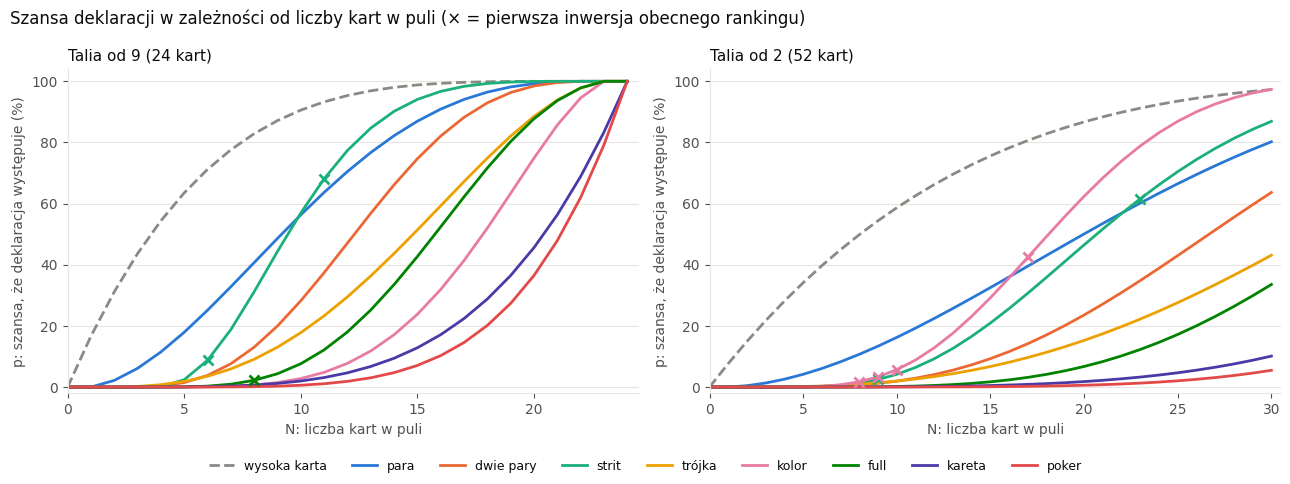

In [6]:
EPS = 1.0  # punkt procentowy (kryterium ε z docs/criteria.md)

def first_inversions(L, max_n):
    # Dla każdej pary (niższy, wyższy) w obecnej kolejności: pierwsze N, gdzie wyższy jest częstszy o >= EPS pp.
    out = {}
    for N in range(1, min(deck_size(L), max_n) + 1):
        p = {c: pct(c, L, N) for c in CURRENT_ORDER}
        for i, low in enumerate(CURRENT_ORDER):
            for high in CURRENT_ORDER[i + 1:]:
                if p[high] > p[low] + EPS and (low, high) not in out:
                    out[(low, high)] = (N, p[high] - p[low])
    return out

def draw(L, max_n, ax):
    D = deck_size(L)
    ns = list(range(0, min(D, max_n) + 1))
    for cat in CURRENT_ORDER:
        ax.plot(ns, [pct(cat, L, n) for n in ns], color=COLORS[cat], lw=2,
                ls="--" if cat == "HIGH" else "-", label=PL[cat])
    for (low, high), (n, gap) in first_inversions(L, max_n).items():
        ax.plot(n, pct(high, L, n), marker="x", color=COLORS[high], ms=7, mew=2, zorder=5)
    ax.set_xlim(0, ns[-1] + 0.5)
    ax.set_ylim(-2, 104)
    ax.set_xlabel("N: liczba kart w puli")
    ax.set_ylabel("p: szansa, że deklaracja występuje (%)")
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_title(f"Talia od {L} ({D} kart)", loc="left", color=INK, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
draw(9, 24, axes[0])
draw(2, 30, axes[1])
fig.suptitle("Szansa deklaracji w zależności od liczby kart w puli (× = pierwsza inwersja obecnego rankingu)",
             x=0.01, ha="left", color=INK, fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=9, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### Inversion table (current ordering)

For each deck: pairs of hands that **break** the current ordering, with the first N where the gap exceeds 1 percentage point. "Margin" is by how many percentage points the higher-position hand is more frequent.

In [7]:
rows = []
for L, max_n in ((9, 24), (7, 32), (5, 40), (2, 40)):
    for (low, high), (n, gap) in first_inversions(L, max_n).items():
        rows.append({"talia (kart)": f"od {L} ({deck_size(L)})", "niższy w rankingu": PL[low],
                     "wyższy w rankingu": PL[high], "pierwsze N": n, "przewaga wyższego (pp)": gap})
df_inv = pd.DataFrame(rows)
df_inv.style.hide(axis="index")

talia (kart),niższy w rankingu,wyższy w rankingu,pierwsze N,przewaga wyższego (pp)
od 9 (24),dwie pary,strit,6,4.948141
od 9 (24),kolor,full,8,1.517395
od 9 (24),para,strit,11,4.436603
od 7 (32),dwie pary,strit,7,3.004050
od 7 (32),para,strit,14,1.808900
od 7 (32),trójka,kolor,15,1.680880
od 5 (40),dwie pary,strit,8,2.222927
od 5 (40),trójka,kolor,11,2.320450
od 5 (40),dwie pary,kolor,12,1.590324
od 5 (40),para,strit,18,2.357767


## 6. Conclusions from M1

**What is established (by formula, exactly):**

- The formulas for p are correct: they agree with full pool enumeration, with simulation, with the brief's control values, with classic poker, and with the game engine.
- **The current ordering is sometimes wrong.** In every deck we studied (24, 32, 40, 52 cards) there are values of N where some "higher" hand is more frequent than a "lower" one by more than 1 pp. Earliest and strongest: **a straight overtakes two pair already at N = 6-9** (for the 24-card deck the margin is nearly 5 pp, visible even in the brief's own control values: straight 8.75% vs two pair 3.80%).
- In the large deck (52) a **flush** overtakes two pair, three of a kind, straight and pair around N ≈ 8-17. A flush is too easy there for its position.

**What we still don't know (and aren't claiming):**

- How **often** a given N actually occurs in a real game. An inversion at N = 23 may be irrelevant if such pools almost never occur. Weighting by the N distribution is M2's job (a Markov chain) and M3's.
- What the "best" ordering is. That's M3, per the criteria in `docs/criteria.md`.

**Uncertainty:** every p value comes from a **formula** (an exact fraction), so it carries no statistical error. Simulation was only used to check the formulas.